# Лабораторная работа 6 — Отбор признаков

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** pandas, numpy, scikit-learn, matplotlib, seaborn

## Цель работы

Изучить и применить различные методы отбора признаков (feature selection) для снижения размерности датасета GTZAN и оценить влияние отбора на качество классификации.

## Теоретическое введение

### Зачем нужен отбор признаков?

При работе с данными высокой размерности возникает ряд проблем:
- **Проклятие размерности** — с ростом числа признаков объём данных, необходимый для обучения, растёт экспоненциально
- **Переобучение** — избыточные признаки могут содержать шум, на котором модель обучается вместо закономерностей
- **Вычислительные затраты** — больше признаков = дольше обучение
- **Интерпретируемость** — модель с меньшим числом признаков легче объяснить

### Категории методов отбора

**1. Фильтрующие методы (Filter)** — оценивают признаки независимо от модели:
- **Mutual Information** — измеряет количество информации, которое признак даёт о целевой переменной
- **Chi-squared** ($\chi^2$) — тест на независимость признака от целевой переменной
- **Дисперсия** — признаки с низкой дисперсией малоинформативны

**2. Обёрточные методы (Wrapper)** — используют модель для оценки подмножеств:
- **RFE** (Recursive Feature Elimination) — итеративно удаляет наименее важные признаки
- **Forward/Backward Selection** — последовательное добавление/удаление признаков

**3. Встроенные методы (Embedded)** — отбор в процессе обучения:
- **LASSO (L1)** — регуляризация обнуляет коэффициенты неважных признаков
- **Feature Importance** — встроенная оценка важности в ансамблевых моделях (Random Forest, Gradient Boosting)

### Консенсусный подход

Разные методы могут давать разные наборы признаков. **Консенсусный подход** — отбираем признаки, выбранные несколькими методами одновременно. Это повышает надёжность отбора.

## Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import (
    mutual_info_classif, chi2, SelectKBest, RFE
)
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
print(f'Размер: {df.shape}')

# Подготовка X и y
drop_cols = ['filename', 'length', 'label']
X = df.drop(columns=drop_cols)
feature_names = X.columns.tolist()

le = LabelEncoder()
y = le.fit_transform(df['label'])

print(f'Признаков: {X.shape[1]}')
print(f'Классы: {le.classes_}')

Размер: (1000, 60)
Признаков: 57
Классы: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [3]:
# Стандартизация для методов, чувствительных к масштабу
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# MinMaxScaler для Chi-squared (требует неотрицательные значения)
mm_scaler = MinMaxScaler()
X_positive = pd.DataFrame(mm_scaler.fit_transform(X), columns=feature_names)

print('Данные подготовлены')

Данные подготовлены


---
## 1. Фильтрующие методы

### 1.1. Mutual Information (взаимная информация)

Mutual Information (MI) измеряет зависимость между признаком и целевой переменной. В отличие от корреляции, MI улавливает и нелинейные зависимости. MI = 0 означает полную независимость.

Порог MI: 0.2270
Отобрано признаков: 28


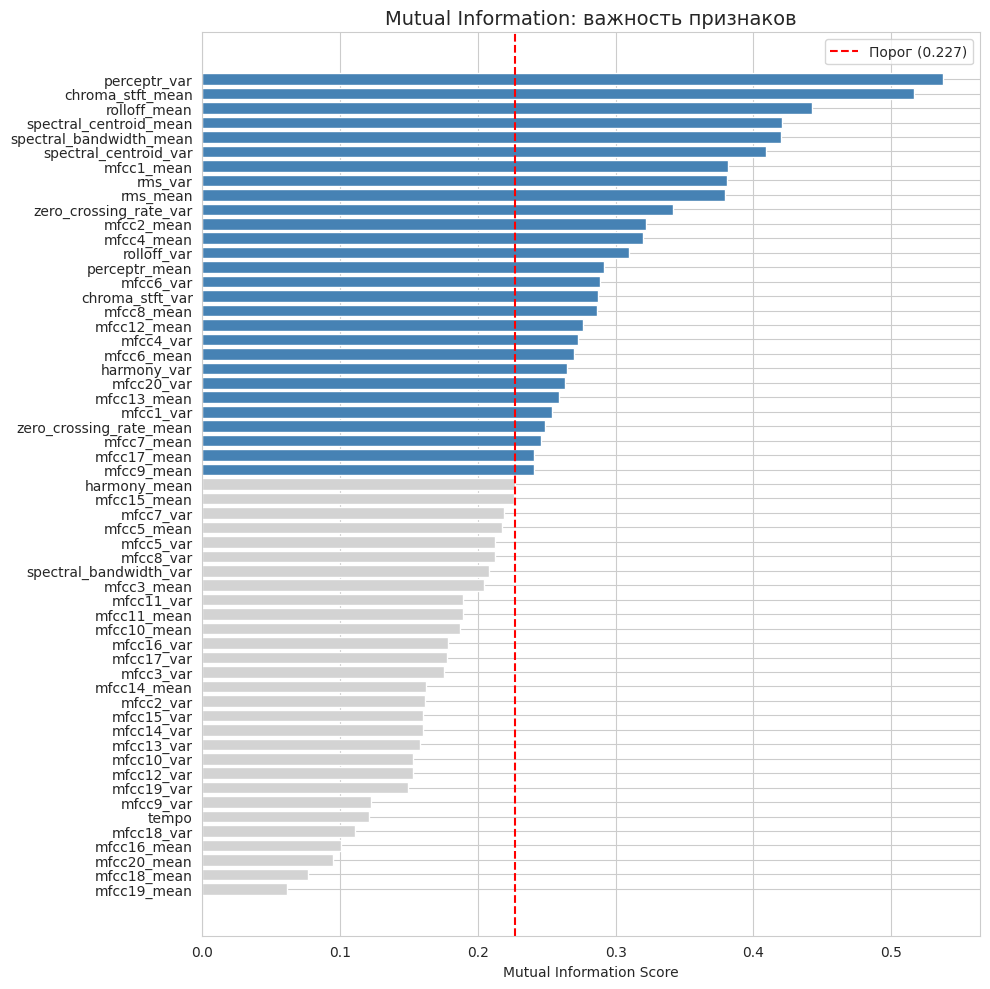

In [4]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Признак': feature_names, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)

# Отбираем топ-20 (порог: MI > медиана)
mi_threshold = mi_df['MI Score'].median()
mi_selected = mi_df[mi_df['MI Score'] > mi_threshold]['Признак'].tolist()
print(f'Порог MI: {mi_threshold:.4f}')
print(f'Отобрано признаков: {len(mi_selected)}')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if s > mi_threshold else 'lightgrey' for s in mi_df['MI Score']]
ax.barh(mi_df['Признак'], mi_df['MI Score'], color=colors)
ax.axvline(x=mi_threshold, color='red', linestyle='--', label=f'Порог ({mi_threshold:.3f})')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information: важность признаков', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.2. Chi-squared тест

Chi-squared ($\chi^2$) тест оценивает зависимость между признаком и целевой переменной. Чем выше значение $\chi^2$, тем сильнее зависимость. Требует неотрицательные данные.

Отобрано по Chi2 (p < 0.05): 27


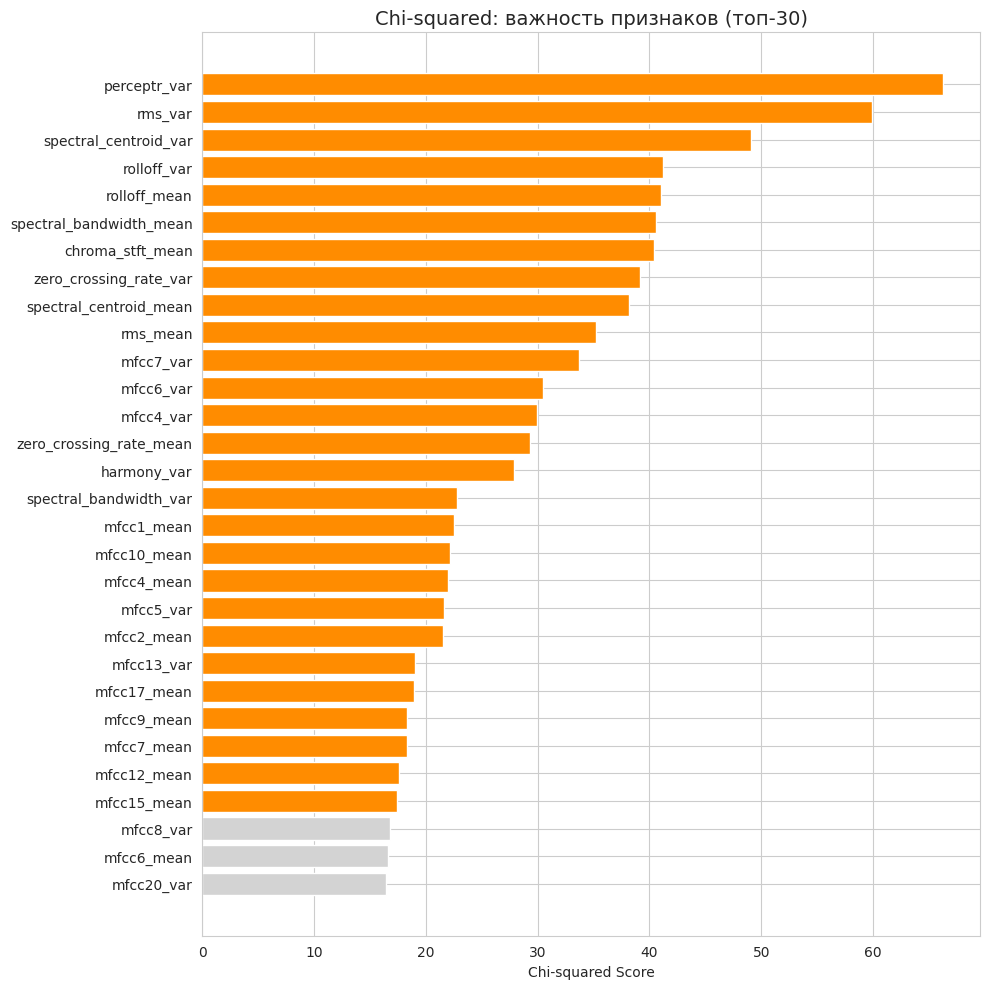

In [5]:
chi2_scores, chi2_pvalues = chi2(X_positive, y)
chi2_df = pd.DataFrame({
    'Признак': feature_names,
    'Chi2 Score': chi2_scores,
    'p-value': chi2_pvalues
}).sort_values('Chi2 Score', ascending=False)

# Отбираем признаки с p-value < 0.05
chi2_selected = chi2_df[chi2_df['p-value'] < 0.05]['Признак'].tolist()
print(f'Отобрано по Chi2 (p < 0.05): {len(chi2_selected)}')

fig, ax = plt.subplots(figsize=(10, 10))
top_chi2 = chi2_df.head(30)
colors = ['darkorange' if p < 0.05 else 'lightgrey' for p in top_chi2['p-value']]
ax.barh(top_chi2['Признак'], top_chi2['Chi2 Score'], color=colors)
ax.set_xlabel('Chi-squared Score')
ax.set_title('Chi-squared: важность признаков (топ-30)', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 2. Обёрточный метод: RFE

**RFE** (Recursive Feature Elimination) итеративно обучает модель и удаляет признак с наименьшим весом, пока не останется заданное количество. Используем LogisticRegression как базовую модель.

In [6]:
lr = LogisticRegression(max_iter=5000, random_state=42, C=1.0)
n_select = len(feature_names) // 2  # отберём половину

rfe = RFE(estimator=lr, n_features_to_select=n_select, step=1)
rfe.fit(X_scaled, y)

rfe_selected = [f for f, s in zip(feature_names, rfe.support_) if s]
print(f'RFE отобрал {len(rfe_selected)} из {len(feature_names)} признаков')

rfe_ranking = pd.DataFrame({
    'Признак': feature_names,
    'Ранг': rfe.ranking_,
    'Отобран': rfe.support_
}).sort_values('Ранг')

rfe_ranking.head(10)

RFE отобрал 28 из 57 признаков


,Признак,Ранг,Отобран
0,chroma_stft_mean,1,True
1,chroma_stft_var,1,True
2,rms_mean,1,True
3,rms_var,1,True
5,spectral_centroid_var,1,True
6,spectral_bandwidth_mean,1,True
7,spectral_bandwidth_var,1,True
8,rolloff_mean,1,True
15,perceptr_var,1,True
10,zero_crossing_rate_mean,1,True


---
## 3. Встроенные методы

### 3.1. LASSO (L1-регуляризация)

LASSO добавляет штраф $\lambda \sum |w_i|$ к функции потерь, что обнуляет коэффициенты неважных признаков. Чем больше $\lambda$ (параметр C в sklearn — обратная величина), тем агрессивнее отбор.

LASSO отобрал 57 ненулевых признаков


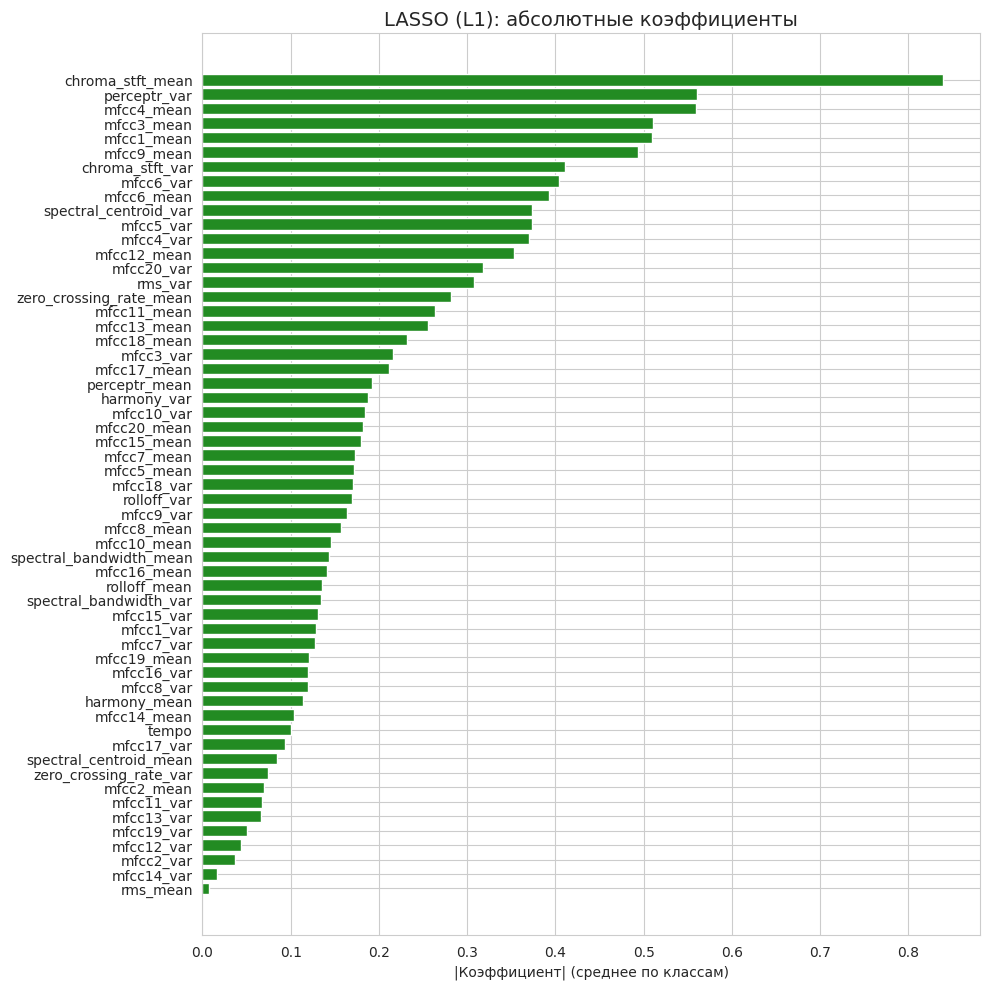

In [7]:
lasso_lr = LogisticRegression(
    penalty='l1', solver='saga', max_iter=5000,
    C=0.5, random_state=42
)
lasso_lr.fit(X_scaled, y)

# Средняя абсолютная величина коэффициентов по всем классам
lasso_coefs = np.abs(lasso_lr.coef_).mean(axis=0)
lasso_df = pd.DataFrame({
    'Признак': feature_names,
    'LASSO |coef|': lasso_coefs
}).sort_values('LASSO |coef|', ascending=False)

lasso_selected = lasso_df[lasso_df['LASSO |coef|'] > 0]['Признак'].tolist()
print(f'LASSO отобрал {len(lasso_selected)} ненулевых признаков')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['forestgreen' if c > 0 else 'lightgrey' for c in lasso_df['LASSO |coef|']]
ax.barh(lasso_df['Признак'], lasso_df['LASSO |coef|'], color=colors)
ax.set_xlabel('|Коэффициент| (среднее по классам)')
ax.set_title('LASSO (L1): абсолютные коэффициенты', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.2. Random Forest Feature Importance

Random Forest оценивает важность признаков по среднему снижению примеси Джини (Gini impurity) при разбиении по данному признаку. Это встроенный механизм, не требующий отдельного этапа.

RF отобрал 28 признаков (порог: медиана = 0.0154)


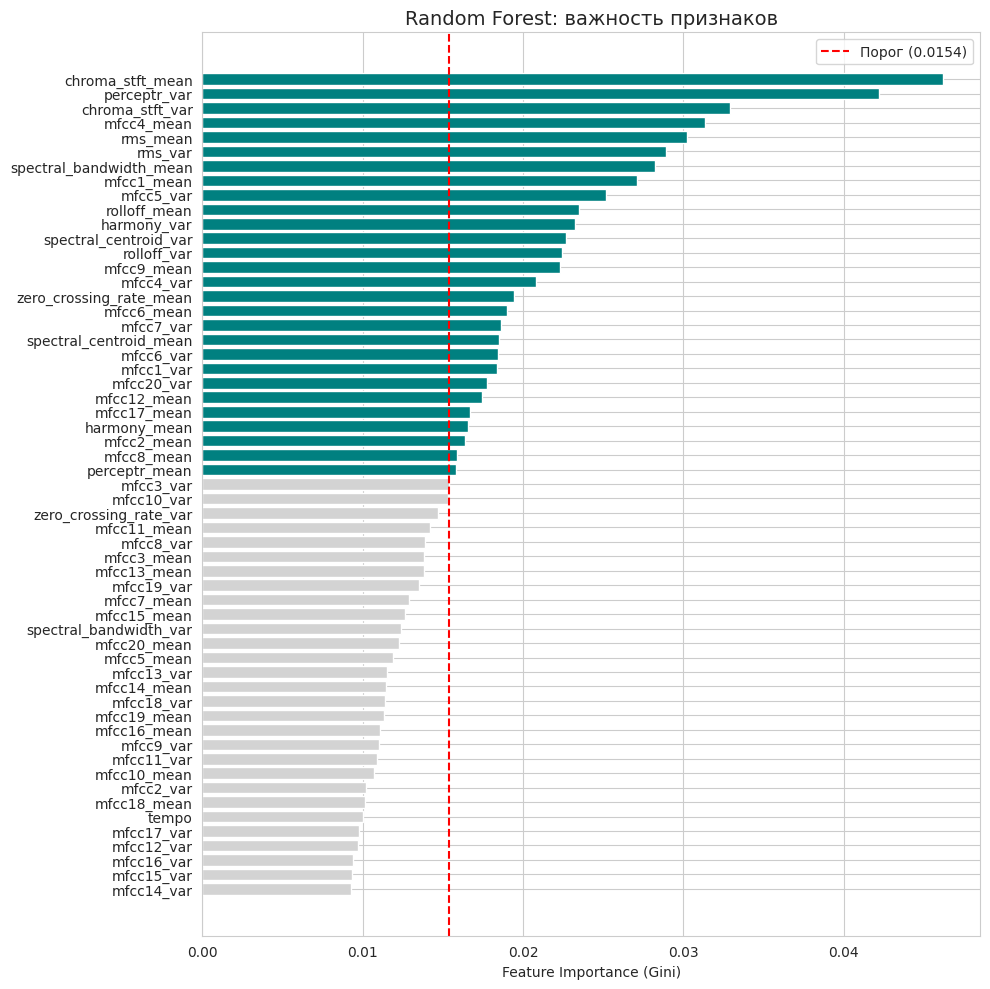

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importance = rf.feature_importances_
rf_df = pd.DataFrame({
    'Признак': feature_names,
    'RF Importance': rf_importance
}).sort_values('RF Importance', ascending=False)

rf_threshold = rf_df['RF Importance'].median()
rf_selected = rf_df[rf_df['RF Importance'] > rf_threshold]['Признак'].tolist()
print(f'RF отобрал {len(rf_selected)} признаков (порог: медиана = {rf_threshold:.4f})')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['teal' if imp > rf_threshold else 'lightgrey' for imp in rf_df['RF Importance']]
ax.barh(rf_df['Признак'], rf_df['RF Importance'], color=colors)
ax.axvline(x=rf_threshold, color='red', linestyle='--', label=f'Порог ({rf_threshold:.4f})')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest: важность признаков', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Консенсусный отбор

Объединим результаты всех 5 методов. Признак считается надёжно отобранным, если его выбрали **не менее 3 из 5** методов.

In [9]:
methods = {
    'MI': set(mi_selected),
    'Chi2': set(chi2_selected),
    'RFE': set(rfe_selected),
    'LASSO': set(lasso_selected),
    'RF': set(rf_selected)
}

# Матрица голосования
vote_matrix = pd.DataFrame(index=feature_names)
for name, selected in methods.items():
    vote_matrix[name] = [1 if f in selected else 0 for f in feature_names]

vote_matrix['Голосов'] = vote_matrix.sum(axis=1)
vote_matrix = vote_matrix.sort_values('Голосов', ascending=False)

consensus_threshold = 3
consensus_features = vote_matrix[vote_matrix['Голосов'] >= consensus_threshold].index.tolist()
print(f'Консенсусный отбор (>={consensus_threshold} голосов): {len(consensus_features)} признаков '
      f'из {len(feature_names)}')
print(f'Сокращение: {(1 - len(consensus_features)/len(feature_names))*100:.1f}%')

Консенсусный отбор (>=3 голосов): 31 признаков из 57
Сокращение: 45.6%


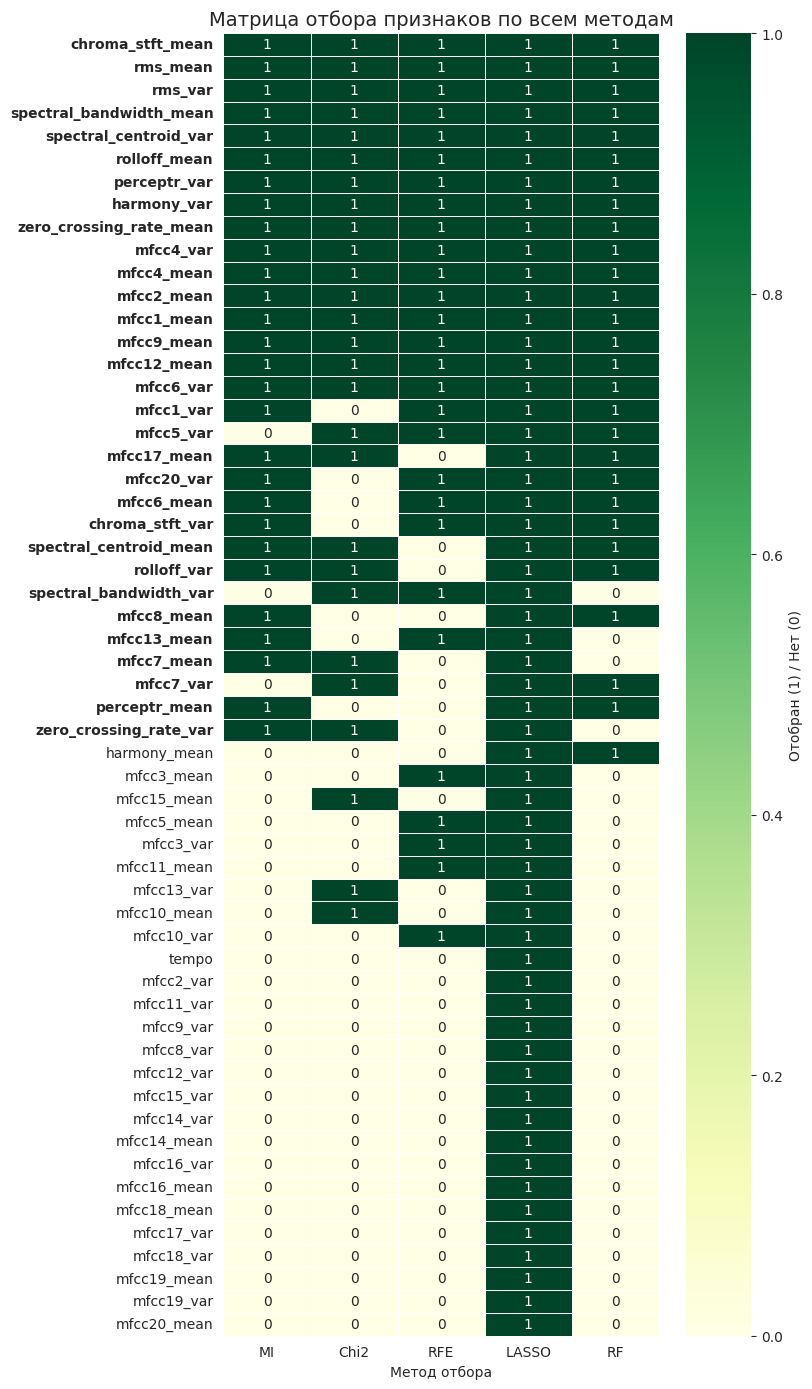

In [10]:
# Тепловая карта голосования
fig, ax = plt.subplots(figsize=(8, 14))
plot_data = vote_matrix.drop(columns='Голосов')

sns.heatmap(
    plot_data, annot=True, fmt='d', cmap='YlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Отобран (1) / Нет (0)'},
    vmin=0, vmax=1
)
ax.set_title('Матрица отбора признаков по всем методам', fontsize=14)
ax.set_xlabel('Метод отбора')

# Подсветим консенсусные признаки
for i, feat in enumerate(vote_matrix.index):
    if feat in consensus_features:
        ax.get_yticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.show()

---
## 5. Оценка качества: все признаки vs отобранные

Сравним качество классификации (accuracy) с использованием кросс-валидации при разных наборах признаков: все, MI, RFE, RF, консенсус.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

feature_sets = {
    f'Все ({len(feature_names)})': feature_names,
    f'MI ({len(mi_selected)})': mi_selected,
    f'RFE ({len(rfe_selected)})': rfe_selected,
    f'RF ({len(rf_selected)})': rf_selected,
    f'Консенсус ({len(consensus_features)})': consensus_features
}

results = {}
for name, features in feature_sets.items():
    scores = cross_val_score(clf, X[features], y, cv=cv, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:25s}  accuracy = {scores.mean():.4f} +/- {scores.std():.4f}')

Все (57)                   accuracy = 0.7060 +/- 0.0322


MI (28)                    accuracy = 0.6900 +/- 0.0270


RFE (28)                   accuracy = 0.7120 +/- 0.0266


RF (28)                    accuracy = 0.7100 +/- 0.0327


Консенсус (31)             accuracy = 0.7040 +/- 0.0263


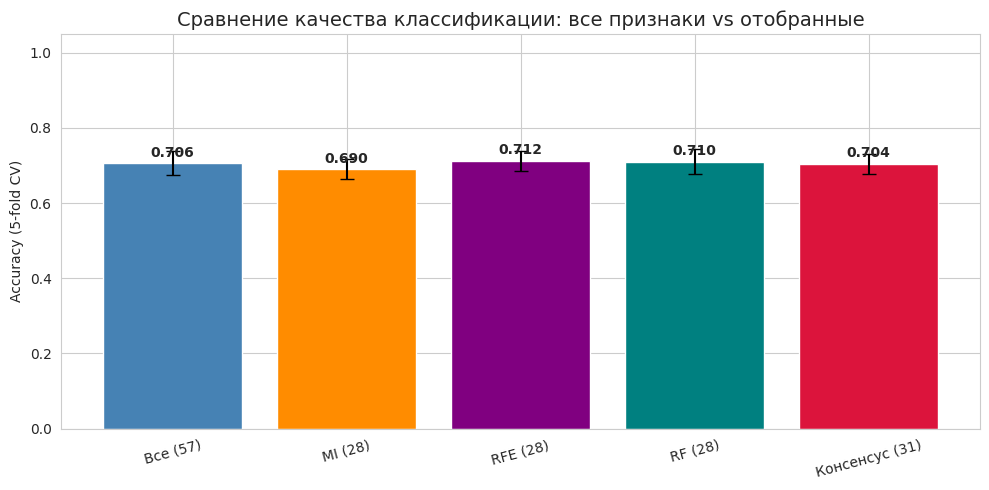

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
means = [r['mean'] for r in results.values()]
stds = [r['std'] for r in results.values()]

colors_bar = ['steelblue', 'darkorange', 'purple', 'teal', 'crimson']
bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors_bar, edgecolor='white')

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{m:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Сравнение качества классификации: все признаки vs отобранные', fontsize=14)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

---
## Выводы

В ходе лабораторной работы мы применили 5 методов отбора признаков к датасету GTZAN:

### Основные результаты:

1. **Фильтрующие методы** (Mutual Information и Chi-squared) работают быстро и не зависят от модели. MI отобрал признаки, отражающие нелинейные зависимости с жанром.

2. **Обёрточный метод** (RFE) учитывает взаимодействие признаков, но более вычислительно затратен. Результат зависит от выбора базовой модели.

3. **Встроенные методы** (LASSO и RF Importance) наиболее практичны — отбор происходит в процессе обучения. Random Forest показал стабильно высокую важность для MFCC-коэффициентов.

4. **Консенсусный подход** позволил выбрать наиболее надёжные признаки, подтверждённые несколькими методами.

5. **Сравнение качества** показало, что отбор признаков может сохранить или даже повысить accuracy при значительном сокращении размерности.

### Практическое значение:

Для датасета GTZAN наиболее информативны: MFCC-коэффициенты (особенно mfcc1-mfcc4), спектральные характеристики (spectral_centroid, rolloff) и perceptr. Этот набор можно использовать в последующих лабораторных работах для обучения моделей классификации жанров.